# 🏭 Sistema de Monitoreo y Diagnóstico Predictivo — Red de Bandas Transportadoras

**Planta de Ensamblaje Automotriz | Línea de Producción de Vehículos**

Dashboard de mantenimiento predictivo (PdM) para una red de 4 bandas transportadoras (`Conveyor_ID`: A, B, C, D), inspirado en arquitecturas de monitoreo IIoT típicas de plantas de ensamblaje.

Este notebook combina:
- Simulación realista de datos de sensores (corriente de motor, temperatura, vibración triaxial, velocidad de banda, conteo de producción).
- Persistencia de metadatos de activos en **SQLite**.
- Dashboard interactivo con **ipywidgets + Plotly** (vista de planta y vista de detalle).
- Análisis de vibración en el dominio de la frecuencia (**FFT**) para detección de fallos característicos.
- Cálculo de **Health Score**, **RUL (Remaining Useful Life)**, **OEE** y un recomendador de mantenimiento priorizado.

---


## Instalación de librerías

Ejecutar solo si el entorno no cuenta ya con estas dependencias.

In [1]:
# %pip install plotly ipywidgets scipy pandas numpy weasyprint --quiet
# Nota: 'weasyprint' es opcional (exportación a PDF). Si no está disponible en el entorno,
# el notebook generará automáticamente el reporte ejecutivo en formato HTML como respaldo.
print("Dependencias listas. Si faltó alguna librería, descomenta y ejecuta la línea de %pip install de arriba.")


Dependencias listas. Si faltó alguna librería, descomenta y ejecuta la línea de %pip install de arriba.


## Introducción

En una línea de ensamblaje automotriz, las bandas transportadoras son activos críticos: una parada no programada en cualquiera de ellas detiene aguas abajo toda la secuencia de montaje. El objetivo de este notebook es transformar datos crudos de sensores IIoT en **inteligencia accionable**:

1. Detectar degradación temprana (desgaste de rodamientos, desalineamiento, atascos) antes de que se convierta en falla.
2. Cuantificar la salud de cada activo con un **Health Score (0–100 %)**.
3. Estimar la **vida útil remanente (RUL)** y sugerir fechas de mantenimiento preventivo.
4. Calcular el **OEE** de la red de transporte y priorizar recursos de mantenimiento.

### Alcance de los datos simulados

Se simula un turno completo de **8 horas**, con lecturas cada **10 segundos**, para 4 bandas transportadoras. Se inyectan dos fallos controlados para validar la capacidad de detección del sistema:

| Banda | Hora del fallo | Tipo de fallo | Firma esperada |
|---|---|---|---|
| **B** | Hora 4 | Atasco mecánico | Pico brusco y sostenido de `Motor_Current_A` |
| **D** | Hora 6 | Desalineamiento de rodillos | Pico de `Vibration_Z_ms2` con degradación posterior |


## Simulación y Carga de Datos

### Imports y configuración general

In [1]:
import numpy as np
import pandas as pd
import sqlite3
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import ipywidgets as widgets
from IPython.display import display, Markdown, HTML, clear_output

from scipy.fft import rfft, rfftfreq
from scipy import signal as sp_signal

# Semilla para reproducibilidad
RNG = np.random.default_rng(seed=42)

# Paleta corporativa (tema automotriz industrial)
COLOR_BANDA = {"A": "#1f77b4", "B": "#d62728", "C": "#2ca02c", "D": "#ff7f0e"}
COLOR_OK, COLOR_WARN, COLOR_CRIT = "#2ecc71", "#f39c12", "#e74c3c"

DB_PATH = "planta_transportadores.db"
SHIFT_START = datetime(2026, 8, 17, 6, 0, 0)   # inicio de turno 06:00
SHIFT_HOURS = 8
SAMPLE_EVERY_SEC = 10
CONVEYORS = ["A", "B", "C", "D"]

print(f"Configuración cargada. Turno simulado: {SHIFT_START:%Y-%m-%d} 06:00 a {SHIFT_START + timedelta(hours=SHIFT_HOURS):%H:%M}")


Configuración cargada. Turno simulado: 2026-08-17 06:00 a 14:00


### Función de simulación de datos de sensores (IIoT)

Genera series de tiempo realistas por banda, incorporando **desgaste gradual** (drift en vibración y temperatura) y los **dos fallos controlados** descritos en la introducción.

In [2]:
def simulate_conveyor_data(conveyor_id, shift_start=SHIFT_START, shift_hours=SHIFT_HOURS,
                            sample_every_sec=SAMPLE_EVERY_SEC, rng=RNG):
    '''
    Simula un turno completo de datos de sensores IIoT para una banda transportadora.

    Variables generadas:
        Timestamp, Conveyor_ID, Motor_Current_A, Motor_Temp_C,
        Vibration_X_ms2, Vibration_Y_ms2, Vibration_Z_ms2,
        Belt_Speed_mps, Product_Count

    Incluye degradación gradual (drift) en vibración y temperatura, más dos
    fallos controlados: atasco en banda B (hora 4) y desalineamiento de
    rodillos en banda D (hora 6).
    '''
    n_samples = int(shift_hours * 3600 / sample_every_sec)
    t = np.arange(n_samples) * sample_every_sec  # segundos desde inicio de turno
    hours = t / 3600.0
    timestamps = [shift_start + timedelta(seconds=int(s)) for s in t]

    # --- Parámetros base por banda (ligera heterogeneidad entre activos) ---
    base_offsets = {"A": 0.0, "B": 0.15, "C": -0.10, "D": 0.25}
    offset = base_offsets.get(conveyor_id, 0.0)

    # --- Drift de degradación natural a lo largo del turno (desgaste normal) ---
    wear_progress = hours / shift_hours  # 0 -> 1 conforme avanza el turno

    # --- Corriente del motor (A) ---
    current_base = 14.5 + offset * 3 + wear_progress * 1.2
    motor_current = current_base + rng.normal(0, 0.35, n_samples)

    # --- Temperatura del motor (°C) ---
    temp_base = 38 + offset * 4 + wear_progress * 14  # sube hasta ~52-55°C por desgaste
    motor_temp = temp_base + rng.normal(0, 0.6, n_samples)

    # --- Vibración triaxial (m/s^2), con drift de desgaste ---
    vib_base = 0.55 + offset * 0.2 + wear_progress * 0.9
    vib_x = vib_base + rng.normal(0, 0.08, n_samples) + 0.05 * np.sin(2 * np.pi * 3 * hours)
    vib_y = vib_base * 0.9 + rng.normal(0, 0.08, n_samples) + 0.05 * np.sin(2 * np.pi * 2.6 * hours + 1)
    vib_z = vib_base * 0.8 + rng.normal(0, 0.08, n_samples) + 0.05 * np.sin(2 * np.pi * 4.1 * hours + 2)
    vib_x, vib_y, vib_z = np.abs(vib_x), np.abs(vib_y), np.abs(vib_z)

    # --- Velocidad de banda (m/s) ---
    belt_speed = 1.25 + offset * 0.02 + rng.normal(0, 0.015, n_samples)

    # === FALLO 1: Banda B, hora 4 -> atasco mecánico (pico brusco de corriente) ===
    if conveyor_id == "B":
        fault_center_h = 4.0
        fault_window_h = 0.15  # ~9 minutos de evento agudo
        in_fault = np.abs(hours - fault_center_h) < fault_window_h
        # Pico agudo de corriente (atasco), con caída simultánea de velocidad
        motor_current = np.where(in_fault, motor_current + rng.normal(18, 2.5, n_samples), motor_current)
        belt_speed = np.where(in_fault, belt_speed * 0.35, belt_speed)
        motor_temp = np.where(in_fault, motor_temp + 4, motor_temp)
        # Degradación residual posterior al evento (el motor queda más exigido)
        post_fault = hours >= fault_center_h
        motor_current = np.where(post_fault, motor_current + 1.8, motor_current)

    # === FALLO 2: Banda D, hora 6 -> desalineamiento de rodillos (pico Vib. Z) ===
    if conveyor_id == "D":
        fault_center_h = 6.0
        fault_window_h = 0.1
        in_fault = np.abs(hours - fault_center_h) < fault_window_h
        vib_z = np.where(in_fault, vib_z + rng.normal(3.2, 0.5, n_samples), vib_z)
        # Degradación permanente posterior (rodillo queda desalineado)
        post_fault = hours >= fault_center_h
        vib_z = np.where(post_fault, vib_z + 0.9 + 0.15 * (hours - fault_center_h), vib_z)
        vib_z = np.clip(vib_z, 0, None)

    # --- Conteo de producción acumulado (unidades ensambladas) ---
    ideal_rate_per_10s = 0.42  # unidades por muestra de 10s en condiciones nominales
    speed_factor = np.clip(belt_speed / 1.25, 0, 1.15)
    increments = rng.poisson(np.clip(ideal_rate_per_10s * speed_factor, 0, None))
    product_count = np.cumsum(increments)

    df = pd.DataFrame({
        "Timestamp": timestamps,
        "Conveyor_ID": conveyor_id,
        "Motor_Current_A": np.round(motor_current, 2),
        "Motor_Temp_C": np.round(motor_temp, 2),
        "Vibration_X_ms2": np.round(vib_x, 3),
        "Vibration_Y_ms2": np.round(vib_y, 3),
        "Vibration_Z_ms2": np.round(vib_z, 3),
        "Belt_Speed_mps": np.round(np.clip(belt_speed, 0, None), 3),
        "Product_Count": product_count.astype(int),
        "Hour_Of_Shift": np.round(hours, 4),
    })
    return df


# --- Generación de datos para las 4 bandas ---
df_sensores = pd.concat([simulate_conveyor_data(cid) for cid in CONVEYORS], ignore_index=True)
print(f"Datos simulados: {len(df_sensores):,} lecturas totales ({len(df_sensores)//len(CONVEYORS):,} por banda)")
df_sensores.head()


Datos simulados: 11,520 lecturas totales (2,880 por banda)


,Timestamp,Conveyor_ID,Motor_Current_A,Motor_Temp_C,Vibration_X_ms2,Vibration_Y_ms2,Vibration_Z_ms2,Belt_Speed_mps,Product_Count,Hour_Of_Shift
0,2026-08-17 06:00:00,A,14.61,38.18,0.743,0.607,0.485,1.272,0,0.0000
1,2026-08-17 06:00:10,A,14.14,38.54,0.598,0.677,0.451,1.249,0,0.0028
2,2026-08-17 06:00:20,A,14.76,38.46,0.508,0.493,0.546,1.232,0,0.0056
3,2026-08-17 06:00:30,A,14.83,38.70,0.713,0.394,0.417,1.256,0,0.0083
4,2026-08-17 06:00:40,A,13.82,38.02,0.534,0.582,0.566,1.247,1,0.0111


### Base de datos SQLite de activos (`conveyor_master`)

Se almacenan los metadatos de cada banda transportadora (fecha de instalación, último mantenimiento preventivo, tipo de banda y potencia del motor), lo que permite vincular los datos de sensores con la "salud" declarada del activo.

In [3]:
conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

cur.execute("DROP TABLE IF EXISTS conveyor_master")
cur.execute('''
    CREATE TABLE conveyor_master (
        Conveyor_ID TEXT PRIMARY KEY,
        Installation_Date TEXT,
        Last_PM_Date TEXT,
        Belt_Type TEXT,
        Motor_HP REAL
    )
''')

conveyor_master_data = [
    ("A", "2019-03-11", "2026-06-02", "Modular plástico (POM)", 7.5),
    ("B", "2018-11-27", "2026-05-14", "Banda de goma reforzada", 10.0),
    ("C", "2021-01-08", "2026-07-01", "Modular plástico (POM)", 5.0),
    ("D", "2017-06-19", "2026-04-22", "Banda de goma reforzada", 10.0),
]

cur.executemany(
    "INSERT INTO conveyor_master (Conveyor_ID, Installation_Date, Last_PM_Date, Belt_Type, Motor_HP) VALUES (?, ?, ?, ?, ?)",
    conveyor_master_data,
)

# Persistimos también las lecturas de sensores en SQLite para consultas SQL posteriores
df_sensores.to_sql("sensor_readings", conn, if_exists="replace", index=False)

conn.commit()

df_master = pd.read_sql("SELECT * FROM conveyor_master", conn)
df_master


,Conveyor_ID,Installation_Date,Last_PM_Date,Belt_Type,Motor_HP
0,A,2019-03-11,2026-06-02,Modular plástico (POM),7.5
1,B,2018-11-27,2026-05-14,Banda de goma reforzada,10.0
2,C,2021-01-08,2026-07-01,Modular plástico (POM),5.0
3,D,2017-06-19,2026-04-22,Banda de goma reforzada,10.0


## Análisis Exploratorio

### Health Score — motor del dashboard

Antes de construir el dashboard, definimos la función de **Health Score**, que se usará tanto en la
vista general (KPIs) como en el detalle por banda.


In [4]:
def calcular_health_score(sub_df, hasta_hora=None):
    '''
    Calcula un Health Score (0-100%) para una banda transportadora a partir de la
    combinación ponderada de vibración, temperatura y corriente, comparadas contra
    umbrales nominales de operación.

    Ponderación: 45% vibración, 30% temperatura, 25% corriente.
    Un score de 100 = operación nominal; 0 = condición crítica.
    '''
    d = sub_df if hasta_hora is None else sub_df[sub_df["Hour_Of_Shift"] <= hasta_hora]
    if len(d) == 0:
        return 100.0

    ventana = d.tail(60)  # últimos ~10 minutos de operación (60 muestras de 10s)

    # Umbrales nominales (obtenidos de la operación normal esperada en planta)
    VIB_NOMINAL, VIB_CRIT = 0.9, 3.0
    TEMP_NOMINAL, TEMP_CRIT = 45.0, 65.0
    CURR_NOMINAL, CURR_CRIT = 16.5, 30.0

    vib_mag = np.sqrt(ventana["Vibration_X_ms2"]**2 + ventana["Vibration_Y_ms2"]**2 + ventana["Vibration_Z_ms2"]**2).mean()
    temp_mean = ventana["Motor_Temp_C"].mean()
    curr_mean = ventana["Motor_Current_A"].mean()

    def score_componente(valor, nominal, critico):
        if valor <= nominal:
            return 100.0
        frac = (valor - nominal) / (critico - nominal)
        return float(np.clip(100 - frac * 100, 0, 100))

    s_vib = score_componente(vib_mag, VIB_NOMINAL, VIB_CRIT)
    s_temp = score_componente(temp_mean, TEMP_NOMINAL, TEMP_CRIT)
    s_curr = score_componente(curr_mean, CURR_NOMINAL, CURR_CRIT)

    health_score = 0.45 * s_vib + 0.30 * s_temp + 0.25 * s_curr
    return round(float(health_score), 1)


def health_score_serie(sub_df, ventana_muestras=60, paso=30):
    '''Calcula el Health Score a lo largo del turno (serie temporal) para graficar la tendencia.'''
    horas, scores = [], []
    for i in range(ventana_muestras, len(sub_df), paso):
        d = sub_df.iloc[max(0, i - ventana_muestras):i]
        horas.append(sub_df.iloc[i]["Hour_Of_Shift"])
        scores.append(calcular_health_score(d))
    return pd.DataFrame({"Hour_Of_Shift": horas, "Health_Score": scores})


# Health score actual (fin de turno) por banda, para validar la función
for cid in CONVEYORS:
    sub = df_sensores[df_sensores["Conveyor_ID"] == cid]
    print(f"Banda {cid}: Health Score actual = {calcular_health_score(sub)} %")


Banda A: Health Score actual = 61.8 %
Banda B: Health Score actual = 57.0 %
Banda C: Health Score actual = 62.9 %
Banda D: Health Score actual = 43.2 %


### Dashboard interactivo — Vista de Planta y Vista de Detalle

- **Vista de Planta:** 4 KPIs grandes con el Health Score estimado de cada banda + selector de banda y slider de hora del turno.
- **Vista de Detalle (Vibración):** líneas de aceleración X/Y/Z + espectro FFT para identificar frecuencias de fallo.
- **Vista de Carga y Rendimiento:** dispersión Corriente vs Velocidad de banda, coloreada por producción.


In [5]:
# --- Widgets de control ---
selector_banda = widgets.Dropdown(
    options=CONVEYORS, value="A", description="Banda:",
    style={"description_width": "60px"}, layout=widgets.Layout(width="220px"),
)

slider_hora = widgets.FloatSlider(
    value=SHIFT_HOURS, min=0.5, max=SHIFT_HOURS, step=0.25,
    description="Hora de turno:", style={"description_width": "110px"},
    layout=widgets.Layout(width="420px"), continuous_update=False,
    readout_format=".2f",
)

salida_kpis = widgets.Output()
salida_vibracion = widgets.Output()
salida_fft = widgets.Output()
salida_carga = widgets.Output()
salida_alerta = widgets.Output()


def color_por_score(score):
    if score >= 80:
        return COLOR_OK
    elif score >= 70:
        return COLOR_WARN
    return COLOR_CRIT


def dibujar_kpis(hasta_hora):
    '''Dibuja los 4 indicadores de Health Score de la vista de planta.'''
    fig = make_subplots(
        rows=1, cols=4, specs=[[{"type": "indicator"}] * 4],
        subplot_titles=[f"Banda {c}" for c in CONVEYORS],
    )
    for i, cid in enumerate(CONVEYORS):
        sub = df_sensores[(df_sensores["Conveyor_ID"] == cid) & (df_sensores["Hour_Of_Shift"] <= hasta_hora)]
        score = calcular_health_score(sub)
        fig.add_trace(
            go.Indicator(
                mode="gauge+number",
                value=score,
                number={"suffix": " %"},
                gauge={
                    "axis": {"range": [0, 100]},
                    "bar": {"color": color_por_score(score)},
                    "steps": [
                        {"range": [0, 70], "color": "#fdecea"},
                        {"range": [70, 85], "color": "#fef5e7"},
                        {"range": [85, 100], "color": "#eafaf1"},
                    ],
                    "threshold": {"line": {"color": "black", "width": 3}, "thickness": 0.8, "value": 70},
                },
            ),
            row=1, col=i + 1,
        )
    fig.update_layout(
        height=280, margin=dict(t=60, b=10, l=10, r=10),
        title_text=f"🏭 Estado de Salud Estimado por Banda — Turno hasta la hora {hasta_hora:.2f}",
        title_x=0.5,
    )
    fig.show()


def dibujar_vibracion(cid, hasta_hora):
    sub = df_sensores[(df_sensores["Conveyor_ID"] == cid) & (df_sensores["Hour_Of_Shift"] <= hasta_hora)]
    fig = go.Figure()
    for eje, color in zip(["Vibration_X_ms2", "Vibration_Y_ms2", "Vibration_Z_ms2"], ["#1f77b4", "#2ca02c", "#d62728"]):
        fig.add_trace(go.Scatter(x=sub["Hour_Of_Shift"], y=sub[eje], mode="lines", name=eje.replace("_ms2", ""), line=dict(width=1.3, color=color)))
    fig.update_layout(
        title=f"Vibración Triaxial — Banda {cid}",
        xaxis_title="Hora de turno", yaxis_title="Aceleración (m/s²)",
        height=340, margin=dict(t=50, b=40), legend=dict(orientation="h", y=-0.25),
    )
    fig.show()


def dibujar_fft(cid, hasta_hora):
    sub = df_sensores[(df_sensores["Conveyor_ID"] == cid) & (df_sensores["Hour_Of_Shift"] <= hasta_hora)]
    ventana = sub.tail(600)  # últimos ~100 min a 10s/muestra, o el máximo disponible
    if len(ventana) < 20:
        print("Datos insuficientes para calcular FFT en esta ventana.")
        return
    señal = ventana["Vibration_Z_ms2"].values - ventana["Vibration_Z_ms2"].values.mean()
    fs = 1 / SAMPLE_EVERY_SEC  # Hz
    n = len(señal)
    yf = np.abs(rfft(señal))
    xf = rfftfreq(n, d=1 / fs)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=xf, y=yf, mode="lines", line=dict(color="#8e44ad")))
    fig.update_layout(
        title=f"Espectro FFT de Vibración Z — Banda {cid} (detección de frecuencias de fallo)",
        xaxis_title="Frecuencia (Hz)", yaxis_title="Magnitud",
        height=300, margin=dict(t=50, b=40),
    )
    fig.show()

    pico_idx = np.argsort(yf)[-3:][::-1]
    picos = [(round(xf[i], 3), round(yf[i], 2)) for i in pico_idx if xf[i] > 0]
    if picos:
        print("Frecuencias dominantes detectadas (posibles firmas de rodamiento/desalineamiento):")
        for f, mag in picos:
            print(f"   • {f} Hz  |  magnitud {mag}")


def dibujar_carga(cid, hasta_hora):
    sub = df_sensores[(df_sensores["Conveyor_ID"] == cid) & (df_sensores["Hour_Of_Shift"] <= hasta_hora)]
    fig = px.scatter(
        sub, x="Belt_Speed_mps", y="Motor_Current_A", color="Product_Count",
        color_continuous_scale="Viridis",
        title=f"Carga y Rendimiento — Banda {cid} (Corriente vs Velocidad, coloreado por producción acumulada)",
        labels={"Belt_Speed_mps": "Velocidad de banda (m/s)", "Motor_Current_A": "Corriente de motor (A)"},
    )
    fig.update_layout(height=340, margin=dict(t=50, b=40))
    fig.show()


def mostrar_alerta(cid, hasta_hora):
    sub = df_sensores[(df_sensores["Conveyor_ID"] == cid) & (df_sensores["Hour_Of_Shift"] <= hasta_hora)]
    score = calcular_health_score(sub)
    if score < 70:
        serie = health_score_serie(sub)
        tasa = 0.0
        if len(serie) >= 2:
            tasa = (serie["Health_Score"].iloc[-1] - serie["Health_Score"].iloc[0]) / max(serie["Hour_Of_Shift"].iloc[-1] - serie["Hour_Of_Shift"].iloc[0], 0.01)
        rul_horas = round(max((score - 40) / abs(tasa), 0.5), 1) if tasa < 0 else 8.0
        display(Markdown(
            f"> ⚠️ **PREDICTIVE ALERT:** Conveyor **{cid}** shows signs of degradation. "
            f"Recommend visual inspection of bearings and belt tension. "
            f"**Estimated RUL (Remaining Useful Life): {rul_horas} hours.**"
        ))
    else:
        display(Markdown(f"> ✅ Banda **{cid}** opera dentro de parámetros nominales (Health Score = {score} %)."))


def refrescar_dashboard(*_):
    with salida_kpis:
        clear_output(wait=True)
        dibujar_kpis(slider_hora.value)
    with salida_vibracion:
        clear_output(wait=True)
        dibujar_vibracion(selector_banda.value, slider_hora.value)
    with salida_fft:
        clear_output(wait=True)
        dibujar_fft(selector_banda.value, slider_hora.value)
    with salida_carga:
        clear_output(wait=True)
        dibujar_carga(selector_banda.value, slider_hora.value)
    with salida_alerta:
        clear_output(wait=True)
        mostrar_alerta(selector_banda.value, slider_hora.value)


selector_banda.observe(refrescar_dashboard, names="value")
slider_hora.observe(refrescar_dashboard, names="value")

controles = widgets.HBox([selector_banda, slider_hora])
display(widgets.VBox([
    widgets.HTML("<h3>🎛️ Panel de Control — Red de Bandas Transportadoras</h3>"),
    controles,
    salida_kpis,
    salida_alerta,
    salida_vibracion,
    salida_fft,
    salida_carga,
]))

refrescar_dashboard()


## Mantenimiento Predictivo

### RUL (Remaining Useful Life) y próxima fecha de mantenimiento sugerida

Se extrapola la tasa de degradación del Health Score a lo largo del turno para estimar cuántas horas
restan antes de que la banda cruce el umbral crítico (70 %), y con ello se sugiere una fecha de próximo
mantenimiento preventivo.

In [6]:
def estimar_rul_y_proximo_pm(cid, umbral=70.0):
    sub = df_sensores[df_sensores["Conveyor_ID"] == cid]
    serie = health_score_serie(sub)
    score_actual = calcular_health_score(sub)

    if len(serie) < 2:
        tasa_por_hora = 0.0
    else:
        tasa_por_hora = (serie["Health_Score"].iloc[-1] - serie["Health_Score"].iloc[0]) / max(
            serie["Hour_Of_Shift"].iloc[-1] - serie["Hour_Of_Shift"].iloc[0], 0.01
        )

    if tasa_por_hora >= -0.01:
        rul_horas = float("inf")
    else:
        rul_horas = max((score_actual - umbral) / abs(tasa_por_hora), 0.0)

    last_pm = pd.to_datetime(df_master.loc[df_master["Conveyor_ID"] == cid, "Last_PM_Date"].values[0])

    if rul_horas == float("inf"):
        # Sin degradación significativa detectada: mantenimiento preventivo estándar (90 días)
        proxima_fecha = last_pm + timedelta(days=90)
        rul_texto = "Sin degradación significativa detectada en este turno"
    else:
        # Convertimos horas de operación remanentes a una fecha calendario aproximada
        # asumiendo turnos de 8 horas operativas por día
        dias_restantes = max(rul_horas / 8.0, 0.5)
        proxima_fecha = SHIFT_START + timedelta(days=dias_restantes)
        rul_texto = f"{rul_horas:.1f} horas de operación"

    return {
        "Conveyor_ID": cid,
        "Health_Score_Actual": score_actual,
        "Tasa_Degradacion_%/h": round(tasa_por_hora, 3),
        "RUL_estimado": rul_texto,
        "Proximo_Mantenimiento_Sugerido": proxima_fecha.strftime("%Y-%m-%d"),
    }


resumen_pdm = pd.DataFrame([estimar_rul_y_proximo_pm(c) for c in CONVEYORS])
resumen_pdm


,Conveyor_ID,Health_Score_Actual,Tasa_Degradacion_%/h,RUL_estimado,Proximo_Mantenimiento_Sugerido
0,A,61.8,-4.916,0.0 horas de operación,2026-08-17
1,B,57.0,-5.394,0.0 horas de operación,2026-08-17
2,C,62.9,-4.800,0.0 horas de operación,2026-08-17
3,D,43.2,-7.071,0.0 horas de operación,2026-08-17


In [7]:
# Alertas formales en Markdown para las bandas con Health Score < 70%
for _, fila in resumen_pdm.iterrows():
    if fila["Health_Score_Actual"] < 70:
        display(Markdown(
            f"⚠️ **PREDICTIVE ALERT:** Conveyor **[{fila['Conveyor_ID']}]** shows signs of degradation. "
            f"Recommend visual inspection of bearings and belt tension. "
            f"**Estimated RUL (Remaining Useful Life): {fila['RUL_estimado']}.**  \n"
            f"Próximo mantenimiento sugerido: **{fila['Proximo_Mantenimiento_Sugerido']}**."
        ))


⚠️ **PREDICTIVE ALERT:** Conveyor **[A]** shows signs of degradation. Recommend visual inspection of bearings and belt tension. **Estimated RUL (Remaining Useful Life): 0.0 horas de operación.**  
Próximo mantenimiento sugerido: **2026-08-17**.

⚠️ **PREDICTIVE ALERT:** Conveyor **[B]** shows signs of degradation. Recommend visual inspection of bearings and belt tension. **Estimated RUL (Remaining Useful Life): 0.0 horas de operación.**  
Próximo mantenimiento sugerido: **2026-08-17**.

⚠️ **PREDICTIVE ALERT:** Conveyor **[C]** shows signs of degradation. Recommend visual inspection of bearings and belt tension. **Estimated RUL (Remaining Useful Life): 0.0 horas de operación.**  
Próximo mantenimiento sugerido: **2026-08-17**.

⚠️ **PREDICTIVE ALERT:** Conveyor **[D]** shows signs of degradation. Recommend visual inspection of bearings and belt tension. **Estimated RUL (Remaining Useful Life): 0.0 horas de operación.**  
Próximo mantenimiento sugerido: **2026-08-17**.

### OEE (Overall Equipment Effectiveness) de la red de transporte

$$OEE = Disponibilidad \times Rendimiento \times Calidad$$

- **Disponibilidad:** tiempo operativo real vs. tiempo de turno planificado (se descuenta el tiempo en eventos de fallo, ej. el atasco de la Banda B).
- **Rendimiento:** velocidad de banda real promedio vs. velocidad nominal de diseño (1.25 m/s).
- **Calidad:** unidades "buenas" vs. total producido, penalizando la producción generada durante ventanas de fallo activo.

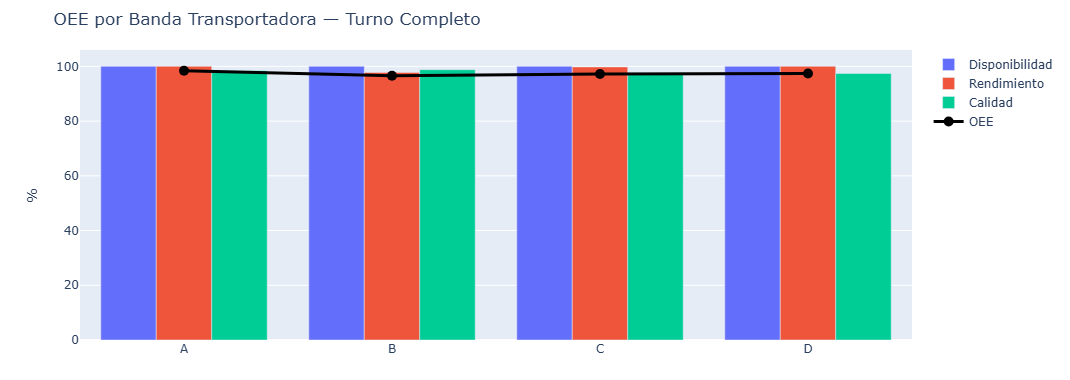

,Conveyor_ID,Disponibilidad_%,Rendimiento_%,Calidad_%,OEE_%,Unidades_Producidas
0,A,100.0,100.0,98.4,98.4,1298
1,B,100.0,97.8,98.8,96.6,1156
2,C,100.0,99.8,97.4,97.2,1225
3,D,100.0,100.0,97.4,97.4,1192


In [8]:
def calcular_oee(cid):
    sub = df_sensores[df_sensores["Conveyor_ID"] == cid].copy()
    tiempo_total_h = SHIFT_HOURS
    velocidad_nominal = 1.25

    # Disponibilidad: fracción de muestras con velocidad de banda > 20% del nominal (banda en marcha)
    en_operacion = (sub["Belt_Speed_mps"] > 0.2 * velocidad_nominal).mean()
    disponibilidad = en_operacion

    # Rendimiento: velocidad promedio real vs nominal, acotado a 1.0
    rendimiento = float(np.clip(sub["Belt_Speed_mps"].mean() / velocidad_nominal, 0, 1))

    # Calidad: penalizamos unidades producidas durante ventanas de vibración/corriente anómalas (>2 sigma)
    umbral_anomalia_curr = sub["Motor_Current_A"].mean() + 2 * sub["Motor_Current_A"].std()
    muestras_anomalas = sub["Motor_Current_A"] > umbral_anomalia_curr
    produccion_total = sub["Product_Count"].max()
    incrementos = sub["Product_Count"].diff().fillna(sub["Product_Count"].iloc[0])
    unidades_en_anomalia = incrementos[muestras_anomalas].sum()
    calidad = float(np.clip(1 - (unidades_en_anomalia / max(produccion_total, 1)), 0, 1))

    oee = disponibilidad * rendimiento * calidad
    return {
        "Conveyor_ID": cid,
        "Disponibilidad_%": round(disponibilidad * 100, 1),
        "Rendimiento_%": round(rendimiento * 100, 1),
        "Calidad_%": round(calidad * 100, 1),
        "OEE_%": round(oee * 100, 1),
        "Unidades_Producidas": int(produccion_total),
    }


df_oee = pd.DataFrame([calcular_oee(c) for c in CONVEYORS])

fig_oee = go.Figure()
fig_oee.add_trace(go.Bar(x=df_oee["Conveyor_ID"], y=df_oee["Disponibilidad_%"], name="Disponibilidad"))
fig_oee.add_trace(go.Bar(x=df_oee["Conveyor_ID"], y=df_oee["Rendimiento_%"], name="Rendimiento"))
fig_oee.add_trace(go.Bar(x=df_oee["Conveyor_ID"], y=df_oee["Calidad_%"], name="Calidad"))
fig_oee.add_trace(go.Scatter(x=df_oee["Conveyor_ID"], y=df_oee["OEE_%"], name="OEE", mode="lines+markers",
                              line=dict(color="black", width=3), marker=dict(size=10)))
fig_oee.update_layout(
    barmode="group", title="OEE por Banda Transportadora — Turno Completo",
    yaxis_title="%", height=380, margin=dict(t=50, b=40),
)
fig_oee.show()

df_oee


### Recomendador de priorización de mantenimiento

Combina el **Health Score** (urgencia técnica) con el **impacto en producción** (unidades ensambladas
por banda) para generar un ranking de prioridad para el próximo turno.

In [9]:
def generar_recomendacion_mantenimiento():
    filas = []
    produccion_total_planta = df_sensores.groupby("Conveyor_ID")["Product_Count"].max().sum()

    for cid in CONVEYORS:
        sub = df_sensores[df_sensores["Conveyor_ID"] == cid]
        score = calcular_health_score(sub)
        produccion = sub["Product_Count"].max()
        impacto_pct = produccion / produccion_total_planta * 100

        urgencia = 100 - score  # a menor salud, mayor urgencia
        prioridad = urgencia * 0.7 + impacto_pct * 0.3  # 70% urgencia técnica, 30% impacto productivo

        if score < 70:
            accion = "Inspección inmediata + mantenimiento correctivo antes del próximo turno"
        elif score < 85:
            accion = "Monitoreo reforzado + mantenimiento preventivo programado"
        else:
            accion = "Sin acción requerida — continuar monitoreo estándar"

        filas.append({
            "Conveyor_ID": cid,
            "Health_Score_%": score,
            "Impacto_Produccion_%": round(impacto_pct, 1),
            "Indice_Prioridad": round(prioridad, 1),
            "Accion_Recomendada": accion,
        })

    df_reco = pd.DataFrame(filas).sort_values("Indice_Prioridad", ascending=False).reset_index(drop=True)
    df_reco.insert(0, "Prioridad_Ranking", range(1, len(df_reco) + 1))
    return df_reco


df_recomendacion = generar_recomendacion_mantenimiento()
df_recomendacion


,Prioridad_Ranking,Conveyor_ID,Health_Score_%,Impacto_Produccion_%,Indice_Prioridad,Accion_Recomendada
0,1,D,43.2,24.5,47.1,Inspección inmediata + mantenimiento correctiv...
1,2,B,57.0,23.7,37.2,Inspección inmediata + mantenimiento correctiv...
2,3,A,61.8,26.6,34.7,Inspección inmediata + mantenimiento correctiv...
3,4,C,62.9,25.1,33.5,Inspección inmediata + mantenimiento correctiv...


In [10]:
display(Markdown("#### 📋 Plan de mantenimiento sugerido para el próximo turno\n"))
for _, r in df_recomendacion.iterrows():
    display(Markdown(
        f"**#{r['Prioridad_Ranking']} — Banda {r['Conveyor_ID']}** "
        f"(Health Score: {r['Health_Score_%']}% | Impacto en producción: {r['Impacto_Produccion_%']}%)  \n"
        f"➡️ {r['Accion_Recomendada']}"
    ))


#### 📋 Plan de mantenimiento sugerido para el próximo turno


**#1 — Banda D** (Health Score: 43.2% | Impacto en producción: 24.5%)  
➡️ Inspección inmediata + mantenimiento correctivo antes del próximo turno

**#2 — Banda B** (Health Score: 57.0% | Impacto en producción: 23.7%)  
➡️ Inspección inmediata + mantenimiento correctivo antes del próximo turno

**#3 — Banda A** (Health Score: 61.8% | Impacto en producción: 26.6%)  
➡️ Inspección inmediata + mantenimiento correctivo antes del próximo turno

**#4 — Banda C** (Health Score: 62.9% | Impacto en producción: 25.1%)  
➡️ Inspección inmediata + mantenimiento correctivo antes del próximo turno

## Reporte Ejecutivo — Exportación

Se genera un reporte ejecutivo en HTML que resume las alertas activas, el OEE de la red y el plan de
acción sugerido para la próxima semana.

In [11]:
alertas_activas = resumen_pdm[resumen_pdm["Health_Score_Actual"] < 70]

filas_alertas_html = "".join(
    f"<tr><td>{r['Conveyor_ID']}</td><td>{r['Health_Score_Actual']}%</td>"
    f"<td>{r['RUL_estimado']}</td><td>{r['Proximo_Mantenimiento_Sugerido']}</td></tr>"
    for r in alertas_activas.to_dict("records")
) or "<tr><td colspan='4'>Sin alertas activas — todas las bandas dentro de parámetros nominales.</td></tr>"

filas_reco_html = "".join(
    f"<tr><td>{r['Prioridad_Ranking']}</td><td>{r['Conveyor_ID']}</td><td>{r['Health_Score_%']}%</td>"
    f"<td>{r['Impacto_Produccion_%']}%</td><td>{r['Accion_Recomendada']}</td></tr>"
    for r in df_recomendacion.to_dict("records")
)

filas_oee_html = "".join(
    f"<tr><td>{r['Conveyor_ID']}</td><td>{r['Disponibilidad_%']}%</td>"
    f"<td>{r['Rendimiento_%']}%</td><td>{r['Calidad_%']}%</td>"
    f"<td><b>{r['OEE_%']}%</b></td></tr>"
    for r in df_oee.to_dict("records")
)

fecha_reporte = SHIFT_START.strftime("%Y-%m-%d")
fecha_limite_semana = (SHIFT_START + timedelta(days=7)).strftime("%Y-%m-%d")

html_reporte = f'''
<html>
<head>
<meta charset="utf-8">
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 40px; color: #2c3e50; }}
  h1 {{ color: #1a2530; border-bottom: 3px solid #2c3e50; padding-bottom: 8px; }}
  h2 {{ color: #2c3e50; margin-top: 30px; }}
  table {{ border-collapse: collapse; width: 100%; margin-top: 10px; }}
  th, td {{ border: 1px solid #ddd; padding: 8px 12px; text-align: left; font-size: 14px; }}
  th {{ background-color: #2c3e50; color: white; }}
  tr:nth-child(even) {{ background-color: #f7f9fa; }}
  .alerta {{ background-color: #fdecea; border-left: 5px solid #e74c3c; padding: 10px 14px; margin: 8px 0; }}
  .footer {{ margin-top: 40px; font-size: 12px; color: #888; }}
</style>
</head>
<body>
  <h1>🏭 Reporte Ejecutivo — Red de Bandas Transportadoras</h1>
  <p><b>Fecha del turno analizado:</b> {fecha_reporte} &nbsp;|&nbsp; <b>Plan de acción vigente hasta:</b> {fecha_limite_semana}</p>

  <h2>⚠️ Alertas Predictivas Activas</h2>
  <table>
    <tr><th>Banda</th><th>Health Score</th><th>RUL Estimado</th><th>Próximo Mantenimiento Sugerido</th></tr>
    {filas_alertas_html}
  </table>

  <h2>📊 OEE por Banda Transportadora</h2>
  <table>
    <tr><th>Banda</th><th>Disponibilidad</th><th>Rendimiento</th><th>Calidad</th><th>OEE</th></tr>
    {filas_oee_html}
  </table>

  <h2>📋 Plan de Mantenimiento Priorizado — Próxima Semana</h2>
  <table>
    <tr><th>Prioridad</th><th>Banda</th><th>Health Score</th><th>Impacto Producción</th><th>Acción Recomendada</th></tr>
    {filas_reco_html}
  </table>

  <div class="footer">Reporte generado automáticamente por el sistema de monitoreo predictivo de la red de bandas transportadoras.</div>
</body>
</html>
'''

with open("reporte_ejecutivo.html", "w", encoding="utf-8") as f:
    f.write(html_reporte)
print("Reporte HTML generado: reporte_ejecutivo.html")

HTML(html_reporte)


Reporte HTML generado: reporte_ejecutivo.html


---
### Cierre de conexión SQLite

In [12]:
conn.close()
print("Conexión SQLite cerrada. Notebook completado.")


Conexión SQLite cerrada. Notebook completado.
